<ipython-input-2-f0185bb09870>:19: RuntimeWarning: overflow encountered in exp
  y=1.0/(1.0+np.exp(-x))


Learning stage 1 fun 0.5907031369810756
Learning stage 2 fun 0.5907031266849057
Optimization terminated successfully.
         Current function value: 0.590703
         Iterations: 2
         Function evaluations: 302
Learning stage 3 fun 97.76067104127203
Learning stage 4 fun 0.46461659381597964
Learning stage 5 fun 0.2757454466862911
Learning stage 6 fun 0.25010433894825457
Learning stage 7 fun 0.1986843310916608
Learning stage 8 fun 0.18003231444769419
Learning stage 9 fun 0.039045291482848896
Learning stage 10 fun 0.03317713132308896
Learning stage 11 fun 0.030479058150111173
Learning stage 12 fun 0.02675220638264488
Learning stage 13 fun 0.025716315364691343
Learning stage 14 fun 0.005455263971475251
Learning stage 15 fun 0.0035599450450000585
Learning stage 16 fun 0.0009223331487813552
Learning stage 17 fun 0.0006462411362196897
Learning stage 18 fun 0.00033078660047844877
Learning stage 19 fun 0.0003206468786194062
Learning stage 20 fun 0.00028934776913025457
Learning stage 21 f

Text(0, 7, 'E=0.00011337014541663137')

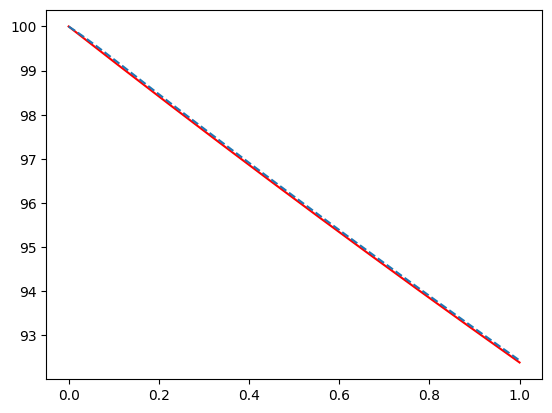

In [ ]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Created on Sat Jul  1 11:05:29 2023

@author: whadyimac
https://pypi.org/project/neurodiffeq/
"""
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt

def f(x,y):
#    df= 2.0*x
    df=-0.1*(y-20)
    return df

def sig(x):
    y=1.0/(1.0+np.exp(-x))
    return y

def yexact(x):
  #y=x**2+1.0
  y=20+80*np.exp(-0.1*x)
  return y

u0=100

def m(x,*params):
    w=params[0]
#w=[w000,w001,w002,w100,w101,w102,w110,w111,w112,w120,w121,w122,w200,w210,w220,b20,b21,b22,b30]
#    0    1    2    3    4    5    6   7     8    9   10   11   12    13   14  15  16  17  18
    w=np.zeros((3,3,3))
    b=np.zeros((4,3))
    w[0,0,0]=params[0][0]
    w[0,0,1]=params[0][1]
    w[0,0,2]=params[0][2]
    w[1,0,0]=params[0][3]
    w[1,0,1]=params[0][4]
    w[1,0,2]=params[0][5]
    w[1,1,0]=params[0][6]
    w[1,1,1]=params[0][7]
    w[1,1,2]=params[0][8]
    w[1,2,0]=params[0][9]
    w[1,2,1]=params[0][10]
    w[1,2,2]=params[0][11]
    w[2,0,0]=params[0][12]
    w[2,1,0]=params[0][13]
    w[2,2,0]=params[0][14]
    b[2,0]=params[0][15]
    b[2,1]=params[0][16]
    b[2,2]=params[0][17]
    b[3,0]=params[0][18]

    r0=w[0,0,0]*x
    r1=w[0,0,1]*x
    r2=w[0,0,2]*x
    r3=w[1,0,0]*sig(r0)
    r4=w[1,0,1]*sig(r0)
    r5=w[1,0,2]*sig(r0)
    r6=w[1,1,0]*sig(r1)
    r7=w[1,1,1]*sig(r1)
    r8=w[1,1,2]*sig(r1)
    r9=w[1,2,0]*sig(r2)
    r10=w[1,2,1]*sig(r2)
    r11=w[1,2,2]*sig(r2)
    r12=sig(r3+r6+r9+b[2,0])
    r13=sig(r4+r7+r10+b[2,1])
    r14=sig(r5+r8+r11+b[2,2])
    r15=w[2,0,0]*r12+w[2,1,0]*r13+w[2,2,0]*r14+b[3,0]
    NN=r15
    y=u0+x*NN
    return y

def E(p,*n):
    s=0.0
    dx=1.0e-6
    for i in range(n[0]):
        dNN=(m(x[i]+dx,p)-m(x[i],p))/dx
        s=s+(dNN-f(x[i],m(x[i],p)))**2
    return s

n=10
x=np.linspace(0,1,n)
#y=np.zeros(n)
yteorica=np.zeros(n)
for i in range(n):
#    y[i]=f(x[i])
    yteorica[i]=yexact(x[i])

x0=np.ones(19)
np.random.seed(177)
#for i in range(19):
#  x0[i]+=np.random.rand()

options={'disp':True,'return_all':True}
lstage=1
def callback(xk):
  global lstage
  print('Learning stage',lstage,'fun',E(xk,n))
  lstage+=1
parameters=minimize(E,x0,args=(n),method='Powell',callback=callback,options=options)
for i in range(19):
  x0[i]+=x0[i]*np.random.rand()
parameters=minimize(E,x0,args=(n),method='Powell',callback=callback,options=options)


nm=100
xm=np.linspace(x[0],x[-1],nm)
ym=np.zeros(nm)
for i in range(nm):
    ym[i]=m(xm[i],parameters.x)

Error_global=E(parameters.x,n)
print('E=',Error_global)

plt.figure()
plt.plot(x,yteorica,'r-')
plt.plot(xm,ym,'--')
plt.annotate('E='+str(Error_global),xy=(0,7))

















In [ ]:
import